
## `Лабораторная работа №3 "Задачи NLP"`



#### Фамилия, имя: Ксавье

Дата выдачи: <span style="color:red">__11 декабря__</span>.

Срок сдачи: <span style="color:red">__25 декабря__</span>.

Максимальная оценка: __10 баллов__




## `Задание 1. Классификация текста с помощью RNN (5 баллов)`



[Данные](https://drive.google.com/drive/folders/1epWf0Wwixxv9juicjdCYYVz351vEe9yM?usp=drive_link) представляют собой тексты разных авторов. Обучающий набор содержит текст - его автора (метку к нему), всего 8 авторов. Тестовый набор содержит только тексты.

Необходимо решить задачу многоклассовой классификации текстов по авторам.

In [ ]:
# загрузим данные
!gdown --folder https://drive.google.com/drive/folders/1epWf0Wwixxv9juicjdCYYVz351vEe9yM?usp=drive_link

Retrieving folder contents
Processing file 1U9L5hXUDWIBdzvTWCyi-UBxHsfbqBmPH test_authors.csv
Processing file 1zfjcjc0S_9DQWZ1MCftKdF9iPct89vFx train_authors.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1U9L5hXUDWIBdzvTWCyi-UBxHsfbqBmPH
To: /content/Text_Author/test_authors.csv
100% 962k/962k [00:00<00:00, 12.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zfjcjc0S_9DQWZ1MCftKdF9iPct89vFx
To: /content/Text_Author/train_authors.csv
100% 5.16M/5.16M [00:00<00:00, 25.6MB/s]
Download completed


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk
nltk.download('punkt_tab')
from tqdm import tqdm_notebook
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Подготовка данных

Загрузим датасет и посмотрим на данные:

In [ ]:
import pandas as pd
train_data = pd.read_csv('/content/Text_Author/train_authors.csv')
train_data.head()

,text,author
0,"Студент, который все это нам рассказал, прилет...",Bulychev
1,"-Что не укладывается в голове,- произнес отец ...",Pratchett
2,"-Ш-ш-ш,- сказал я.- Спи.\n-Не могу,- ответила ...",King
3,-В Севастополь? Новое задание имеет отношение ...,Akunin
4,"-Ты прав,- сказал Сева.- Даже если это космиче...",Bulychev


In [ ]:
test_data = pd.read_csv('/content/Text_Author/test_authors.csv')
test_data.head()

,text
0,-Не выглядывал еще. Дрыхнет… Почему да почему?...
1,"Идти ему было немного; он даже знал, сколько ш..."
2,Придется вернуться в самое изголовье и начать ...
3,"-С ума сойти,- сказал отец. Он обернулся, увид..."
4,"Во-вторых, положение Петра после захвата власт..."


In [ ]:
# Назначим каждому автору идентификатор
writers = ['Akunin', 'Bulychev', 'Chehov', 'Dostoevsky', 'Gogol', 'King',
          'Pratchett', 'Remark']
writers_to_label = {writer: i for i, writer in enumerate(writers)}
label_to_writers = {i: writer for i, writer in enumerate(writers)}

Подготовим данные для задачи классификации текстов по авторам, преобразуя сырые данные в словарь dataset['train'] и dataset['test'].


In [ ]:
dataset = {}

dataset['train'] = [{'text':text, 'author':writers_to_label[label]} \
              for text, label in zip(np.array(train_data['text']), np.array(train_data['author']))]
dataset['test'] = [{'text':text, 'author': 0} \
              for text in np.array(test_data['text'])]

Можно сделать иначе используя класс `Dataset`.


In [ ]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, texts, authors):
        self.texts = texts
        self.authors = authors

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {'text': self.texts[idx], 'author': self.authors[idx]}

**1)** Заведите Dataloader для загрузки данных нейронную сеть.

**2)** Разработайте и обучите RNN  на тренировочных данных.

Вкачестве рекуррентных слоёв можно выбрать:
- базовый RNN,
- LSTM,
- GRU,
- Применение двунаправленных рекуррентных слоев (Bidirectional RNN/LSTM/GRU).

**3)** Проведите эксперитенты с:
- Увеличением глубины модели. Используйте параметр `num_layers` для создания многослойной RNN.
При этом выходы каждого предыдущего слоя передаются в качестве входов следующему.

- Агрегацией выходных последовательностей. Помимо стандартных подходов (max, mean, last), рассмотрите, например, конкатенацию различных видов агрегации, использование различных пулинговых операций, или Ваш вариант.

**4)** Сделайте выводы и выберите модель с лучшей accuracy.

#### 1. DataLoader

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return word_tokenize(text)

In [ ]:
tokenized_texts = [preprocess_text(item['text']) for item in dataset['train']]

counter = Counter()
for tokens in tokenized_texts:
    counter.update(tokens)

MAX_VOCAB_SIZE = 20000

most_common = counter.most_common(MAX_VOCAB_SIZE)

word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1

idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)

vocab_size

20002

In [ ]:
def encode_text(tokens, word2idx):
    return [word2idx.get(token, word2idx['<UNK>']) for token in tokens]

In [ ]:
class RNNDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=300):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = preprocess_text(self.texts[idx])
        ids = encode_text(tokens, self.word2idx)

        ids = ids[:self.max_len]
        ids += [0] * (self.max_len - len(ids))

        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
texts = np.array(train_data['text'])
labels = np.array(train_data['author'].map(writers_to_label))

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

train_dataset = RNNDataset(X_train, y_train, word2idx)
val_dataset = RNNDataset(X_val, y_val, word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
batch = next(iter(train_loader))
batch['input_ids'].shape, batch['labels'].shape

(torch.Size([32, 300]), torch.Size([32]))

#### 2. RNN (GRU)

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_classes=8,
        num_layers=1,
        bidirectional=False
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.rnn = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        rnn_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.fc = nn.Linear(rnn_output_dim, num_classes)

    def forward(self, input_ids):
        """
        input_ids: [B, T]
        """
        x = self.embedding(input_ids)
        _, h_n = self.rnn(x)

        h_last = h_n[-1]
        logits = self.fc(h_last)

        return logits

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=len(writers),
    num_layers=1,
    bidirectional=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_epoch(model, dataloader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total


@torch.no_grad()
def eval_epoch(model, dataloader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc='Validation'):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        logits = model(input_ids)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2046773.8264207244


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9757, acc: 0.2177 | Val loss: 1.9258, acc: 0.1902

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.7146, acc: 0.3526 | Val loss: 1.9091, acc: 0.2565

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.6250, acc: 0.3749 | Val loss: 1.9403, acc: 0.2017


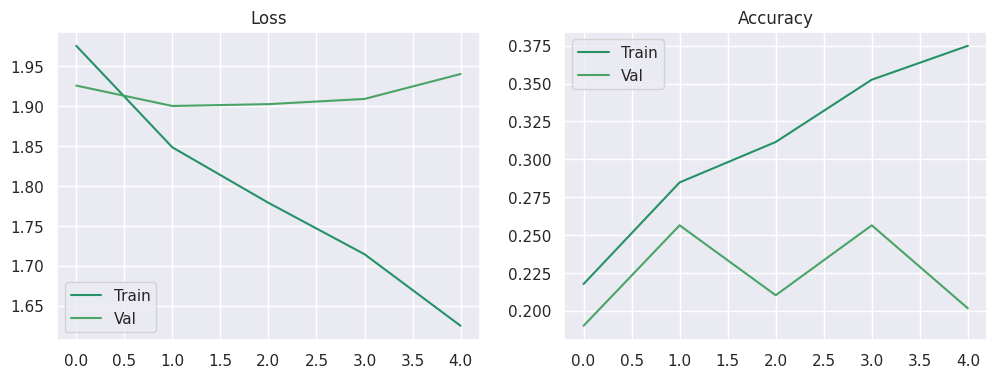

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.show()

> Точность базовой RNN-модели показывает значения выше случайного угадывания, но из-за простой архитектуры и отсутствия механизмов более глубокого контекстного анализа текста, качество остаётся ограниченным

#### 3. GRU / LSTM

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=2,
        num_classes=8,
        rnn_type='gru',
        bidirectional=False,
        aggregation='last'
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.aggregation = aggregation
        self.bidirectional = bidirectional

        rnn_cls = {
            'rnn': nn.RNN,
            'gru': nn.GRU,
            'lstm': nn.LSTM
        }[rnn_type]

        self.rnn = rnn_cls(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        rnn_out_dim = hidden_dim * (2 if bidirectional else 1)

        if aggregation == 'concat':
            rnn_out_dim *= 3

        self.fc = nn.Linear(rnn_out_dim, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        outputs, hidden = self.rnn(x)

        if self.aggregation == 'last':
            if self.bidirectional:
                out = torch.cat((outputs[:, -1, :outputs.size(2)//2],
                                 outputs[:, 0, outputs.size(2)//2:]), dim=1)
            else:
                out = outputs[:, -1]

        elif self.aggregation == 'mean':
            out = outputs.mean(dim=1)

        elif self.aggregation == 'max':
            out, _ = outputs.max(dim=1)

        elif self.aggregation == 'concat':
            last = outputs[:, -1]
            mean = outputs.mean(dim=1)
            max_, _ = outputs.max(dim=1)
            out = torch.cat([last, mean, max_], dim=1)

        return self.fc(out)

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    num_layers=3,           #увеличил глубину
    rnn_type='gru',
    aggregation='last'
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2056261.1679537296


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9498, acc: 0.2185 | Val loss: 1.9006, acc: 0.2046

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.6898, acc: 0.3280 | Val loss: 1.8970, acc: 0.2738

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.5654, acc: 0.3821 | Val loss: 1.9466, acc: 0.2161


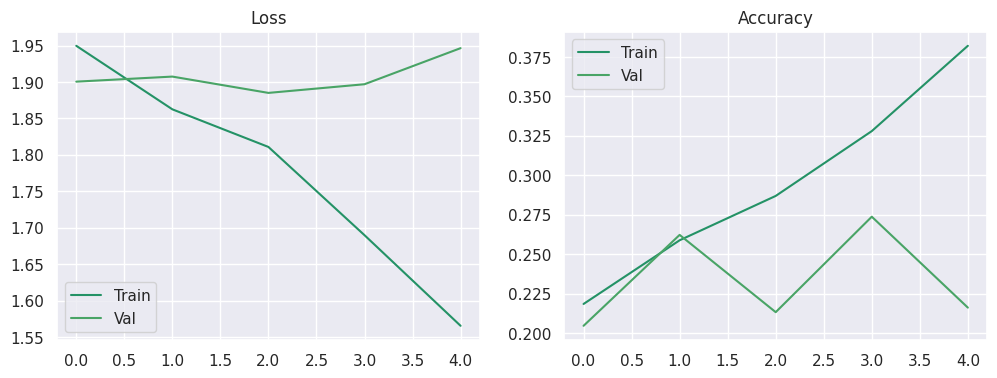

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.show()

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    num_layers=3,
    rnn_type='gru',
    aggregation='concat'
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2056135.280636549


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9245, acc: 0.2610 | Val loss: 1.8606, acc: 0.2738

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.2884, acc: 0.5631 | Val loss: 1.4107, acc: 0.4726

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 0.9527, acc: 0.6885 | Val loss: 1.3148, acc: 0.5245


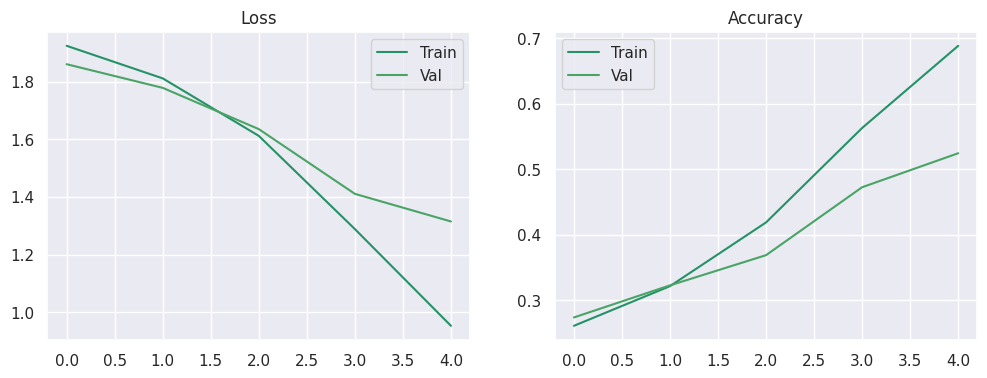

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.show()

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    num_layers=3,
    rnn_type='gru',
    aggregation='mean'
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2054462.7462577224


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9318, acc: 0.2523 | Val loss: 1.8294, acc: 0.2911

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.2294, acc: 0.5328 | Val loss: 1.4575, acc: 0.4352

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.0195, acc: 0.6323 | Val loss: 1.5908, acc: 0.4438


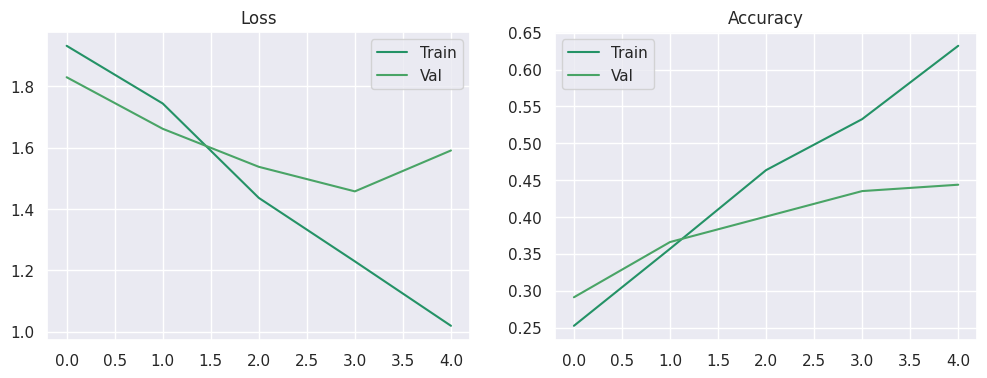

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.show()

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    num_layers=3,
    rnn_type='gru',
    aggregation='max'
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2055576.4879770875


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9496, acc: 0.2480 | Val loss: 1.8780, acc: 0.2565

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.4393, acc: 0.5076 | Val loss: 1.5909, acc: 0.4352

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.0992, acc: 0.6539 | Val loss: 1.5291, acc: 0.4409


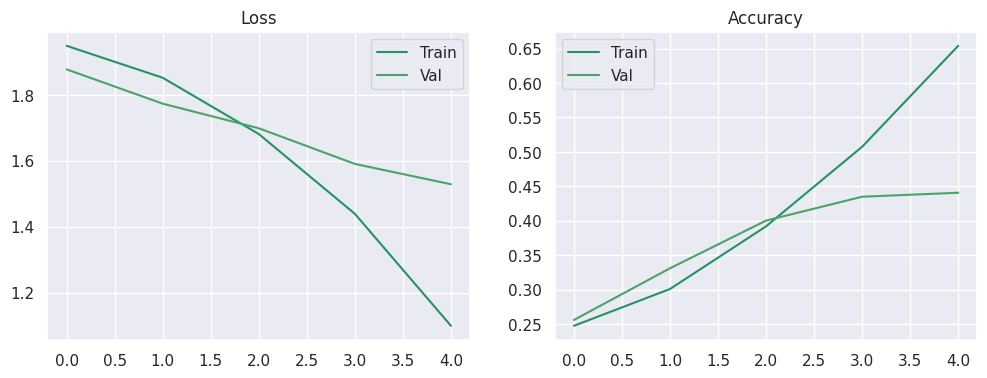

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.show()

> В рамках экспериментов с агрегацией выходных состояний сети были рассмотрены методы last, mean, max и их конкатенация.
Агрегация last показывает наихудшее качество, из-за потерь информации о последовательности.
Агрегации mean и max демонстрируют более стабильное обучение и лучшее обобщение.
Наилучший результат был получен при использовании конкатенации агрегаций (last + mean + max), которая позволяет сохранять информацию о последовательности в различных представлениях.
Таким образом, модель с агрегацией concat была выбрана как оптимальная по метрике accuracy.

#### 4. Final model

In [ ]:
model = RNNClassifier(
    vocab_size=vocab_size,
    num_layers=3,
    rnn_type='gru',
    aggregation='concat'
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(sum(p.abs().sum().item() for p in model.parameters()))

2056905.5733166635


In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.9267, acc: 0.2596 | Val loss: 1.8778, acc: 0.2680

Epoch 2/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.3565, acc: 0.5220 | Val loss: 1.5382, acc: 0.4092

Epoch 5/5


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Train loss: 1.0258, acc: 0.6561 | Val loss: 1.4100, acc: 0.5014


### Инференс модели

Ниже функция для оценки точности модели на данных из DataLoader.

Здесь model — ваша обученная модель, dataloader — test_dataloader, построенный на основе тестовой части данных (dataset['test']).

In [ ]:
test_texts = np.array([item['text'] for item in dataset['test']])

dummy_labels = np.zeros(len(test_texts))

test_dataset = RNNDataset(
    texts=test_texts,
    labels=dummy_labels,
    word2idx=word2idx
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
def get_predictions(model, dataloader):
    """
    Calculate accuracy on data from dataloader.
    """

    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in tqdm_notebook(dataloader,
                                   desc=f'Evaluating'):
            # Получаем предсказания
            input_ids = batch['input_ids'].to(device)
            logits = model(input_ids)
             # Для многоклассовой классификации
            predictions.append(logits.argmax(dim=1))

    predictions = torch.cat(predictions).data.cpu().numpy()

    return predictions

In [ ]:
predictions = get_predictions(model, test_dataloader)
predictions = [label_to_writers[x] for x in predictions]
predictions

/tmp/ipython-input-753666954.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm_notebook(dataloader,


Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

['Pratchett',
 'Dostoevsky',
 'Akunin',
 'Bulychev',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Akunin',
 'Pratchett',
 'Pratchett',
 'Akunin',
 'Akunin',
 'Dostoevsky',
 'Dostoevsky',
 'Bulychev',
 'Akunin',
 'King',
 'Pratchett',
 'Akunin',
 'Pratchett',
 'Akunin',
 'Pratchett',
 'Akunin',
 'Akunin',
 'Akunin',
 'Pratchett',
 'Akunin',
 'King',
 'Chehov',
 'Pratchett',
 'Akunin',
 'King',
 'King',
 'Akunin',
 'Akunin',
 'Pratchett',
 'Akunin',
 'Pratchett',
 'Akunin',
 'King',
 'Pratchett',
 'Bulychev',
 'Pratchett',
 'King',
 'Bulychev',
 'Chehov',
 'Akunin',
 'Pratchett',
 'Akunin',
 'Akunin',
 'Pratchett',
 'Akunin',
 'Akunin',
 'King',
 'Bulychev',
 'Bulychev',
 'King',
 'Akunin',
 'Akunin',
 'Akunin',
 'King',
 'Akunin',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Akunin',
 'Akunin',
 'Akunin',
 'Chehov',
 'Gogol',
 'Akunin',
 'King',
 'Akunin',
 'Akunin',
 'King',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'Pratchett',
 'King',
 'Akuni

### Сохраните результат

In [ ]:
np.save('submission_rnn03.npy', predictions, allow_pickle=True)
print('Ответ сохранен в файл `submission_rnn03.npy`')

Ответ сохранен в файл `submission_rnn03.npy`


## `Задание 2. Классификация текста с помощью предобученной языковой модели BERT (3 балла)`

Рассматривается [датасет](https://drive.google.com/drive/folders/151O9W-yp6TMP0Wmrm_wzbu8F7sq4cm_4?usp=sharing)
**SST-2** (Stanford Sentiment Treebank версии 2).


In [ ]:
import os
import random

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython.display import clear_output

### Загрузка данных


`holdout_texts.npy` - файл содержит holdout выборку.

holdout выборка - это отдельная часть неразмеченных данных, которая НЕ используется при обучении модели и служит исключительно для финальной оценки её качества после завершения всех экспериментов.

`STT2_train_task.tsv` - файл с обучающей выборкой.


In [ ]:
# загрузим данные
!gdown --folder https://drive.google.com/drive/folders/151O9W-yp6TMP0Wmrm_wzbu8F7sq4cm_4?usp=sharing

Retrieving folder contents
Processing file 1ifRDFC5b9V08XzWo1my7XCCGh_ji3jt1 holdout_texts.npy
Processing file 1k-dMMYNPqOjeppDoTWd7nR3Ln2VI0ZVv STT2_train_task.tsv.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1ifRDFC5b9V08XzWo1my7XCCGh_ji3jt1
To: /content/SST2/holdout_texts.npy
100% 45.4k/45.4k [00:00<00:00, 63.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k-dMMYNPqOjeppDoTWd7nR3Ln2VI0ZVv
To: /content/SST2/STT2_train_task.tsv.txt
100% 720k/720k [00:00<00:00, 9.47MB/s]
Download completed


In [ ]:
# преобразуем holdout-выборку в numpy.array
texts_holdout = np.load('/content/SST2/holdout_texts.npy', allow_pickle=True)
texts_holdout[:5]


array(['gee , a second assassin shot kennedy ?',
       "from the big giant titles of the opening credits to elmer bernstein 's perfectly melodic score , haynes gets just about everything right",
       'the movie is well shot and very tragic , and one to ponder after the credits roll',
       'the movie quickly drags on becoming boring and predictable',
       "a mixed bag of a comedy that ca n't really be described as out of this world"],
      dtype=object)

In [ ]:
# Загрузим обучающие и тестовые размеченные данные
df = pd.read_csv(
    '/content/SST2/STT2_train_task.tsv.txt',
    delimiter='\t',
    header=None
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6920 entries, 0 to 6919
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6920 non-null   object
 1   1       6920 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 108.3+ KB


In [ ]:
# реализуем простое разделение на обучающую и тестовую части
# 73% - обучающая, 27% - тестовая
texts_train = df[0].values[:5000]
y_train = df[1].values[:5000]
texts_test = df[0].values[5000:]
y_test = df[1].values[5000:]


**1)** Напишите функцию получения эмбеддингов.

Сначала необходимо получить эмбендинги предложений с помощью обученной `BERT':

- Загрузить предобученный токенизатор и модель.

- Токенизировать текст с добавлением специальных токенов и преобразовать в тензоры.

Функция
`tokenizer.encode(text, add_special_tokens=True)`
возвращает ID токенов.

- Пропустить через модель и получить выходы.

- Извлечь эмбеддинг для всего предложения (возьмем скрытое состояние, соответствующее [CLS] токену).



In [ ]:
def get_bert_embeddings(text, model, tokenizer, pooling_strategy='cls'):
    """
    Получение эмбеддингов текста с помощью BERT

    Args:
        text: строка или список строк
        model: предобученная модель BERT
        tokenizer: токенизатор BERT
        pooling_strategy: стратегия пулинга ('cls', 'mean', 'max')

    Returns:
        Векторное представление текста
    """

    model.eval()

    if isinstance(text, str):
        text = [text]

    with torch.no_grad():
        encoded = tokenizer(
            text,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

        encoded = {k: v.to(model.device) for k, v in encoded.items()}

        outputs = model(**encoded)
        last_hidden = outputs.last_hidden_state

        if pooling_strategy == 'cls':
            embeddings = last_hidden[:, 0, :]

        elif pooling_strategy == 'mean':
            embeddings = last_hidden.mean(dim=1)

        elif pooling_strategy == 'max':
            embeddings, _ = last_hidden.max(dim=1)

        else:
            raise ValueError(f"Unknown pooling strategy: {pooling_strategy}")

    return embeddings.cpu().numpy()

In [ ]:
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased').to(device)

In [ ]:
emb = get_bert_embeddings(
    "еtest msg",
    bert_model,
    tokenizer
)

emb.shape

(1, 768)

**2)** Обучите логистическую регрессию

Датасет для обучения логистической регрессии состоит из векторов, полученных из предобученной модели BERT. В качестве признаков используются эмбеддинги токена [CLS], которые извлекаются из выходного слоя трансформерного блока модели.
Каждая строка датасета соответствует отдельному предложению, а столбцы представляют активации скрытых нейронов полносвязного слоя, следующего за трансформерной архитектурой. Эти векторные представления служат входными признаками для классификатора.

Ваша модель должна давать точность > 80%

In [ ]:
X_train_emb = get_bert_embeddings(
    texts_train.tolist(),
    bert_model,
    tokenizer,
    pooling_strategy='cls'
)

X_test_emb = get_bert_embeddings(
    texts_test.tolist(),
    bert_model,
    tokenizer,
    pooling_strategy='cls'
)

X_holdout_emb = get_bert_embeddings(
    texts_holdout.tolist(),
    bert_model,
    tokenizer,
    pooling_strategy='cls'
)

X_train_emb.shape, X_test_emb.shape, X_holdout_emb.shape

((5000, 768), (1920, 768), (500, 768))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
logreg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

logreg.fit(X_train_emb, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
train_preds = logreg.predict(X_train_emb)
test_preds = logreg.predict(X_test_emb)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

train_acc, test_acc

(0.9102, 0.8442708333333333)

In [ ]:
train_probs = logreg.predict_proba(X_train_emb)
test_probs = logreg.predict_proba(X_test_emb)
holdout_probs = logreg.predict_proba(X_holdout_emb)


Сохраните в словарь `out_dict` вероятности принадлежности к нулевому и первому классу соответственно, для кадой выборки:

In [ ]:
out_dict = {
    'train': train_probs,
    'test': test_probs,
    'holdout': holdout_probs
}

In [ ]:
out_dict['train'].shape, out_dict['test'].shape, out_dict['holdout'].shape

((5000, 2), (1920, 2), (500, 2))

### Сохраните результат

In [ ]:
np.save('submission_bert03.npy', out_dict, allow_pickle=True)
print('Ответ сохранен в файл `submission_bert03.npy`')

Ответ сохранен в файл `submission_bert03.npy`


## `Задание 3. Реализовать механизм внимания (2 балла)`


Рассмотрим архитектуру энкодера-декодера, где энкодер преобразует входную последовательность в набор скрытых состояний $h_{e1}, ..., h_{eN}$, а декодер генерирует выходную последовательность, используя свои состояния $h_{dt}$ в каждый момент времени $t$.


**Вектор внимания** $a_{dt}$ в момент времени $t$ представляет собой распределение важности по всем состояниям энкодера:


$$a_{dt} = [a_{i,t},...,a_{N, t}]$$


где каждый элемент $a_{i, t} = f(h_{ei}, h_{dt})$ вычисляется с помощью функции внимания $f$, оценивающей релевантность $i$-го состояния энкодера текущему состоянию декодера.

**Типы функций внимания**:

1. **Внимание на основе скалярного произведения (Dot-Product Attention)**
Самый простой и вычислительно эффективный подход, непосредственно измеряющий сходство между векторами:

$$f(h_{ei}, h_{dt}) = h_{dt}^Th_{ei}$$

Преимущества:

- Минимальные вычислительные затраты.

- Не требует дополнительных обучаемых параметров.

2. **Мультипликативное внимание (Multiplicative Attention)**

Вводит обучаемую матрицу весов $W$ для моделирования взаимодействий между пространствами энкодера и декодера:

$$f(h_{ei}, h_{dt}) = h_{dt}^T*W*h_{ei}$$

Преимущества:

- Позволяет моделировать более сложные взаимосвязи.

- Матрица $W$ адаптируется в процессе обучения.

- Эффективнее скалярного произведения при разных размерностях векторов.

3. **Аддитивное внимание (Additive Attention)**
Использует двухслойную нейронную сеть с нелинейной активацией (например, tanh) для вычисления оценки внимания:

$$f(h_{ei}, h_{dt}) = v^T*tanh(W_1*h_{ei}+W_2*h_{dt})$$

где $W_1$, $W_2$ — матрицы весов, а $v$ — вектор весов для получения скалярного значения.

Преимущества:

- Более выразительная модель за счет нелинейности.

- Подходит для случаев, когда прямого сходства между векторами недостаточно.



In [ ]:
import os
import random

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython.display import clear_output


#### Dot product attention (пример реализации)

Рассмотрим единственное состояние энкодера – вектор с размерностью `(n_hidden, 1)`, где `n_hidden = 3` - размерность вектора, который определяет единственное состояние энкодера:

Text(0.5, 1.0, 'Decoder state')

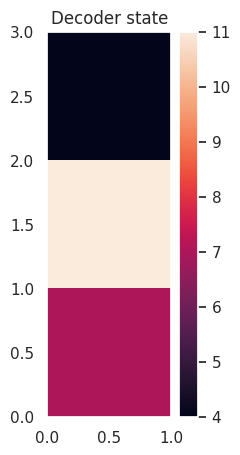

In [ ]:
decoder_hidden_state = np.array([7, 11, 4]).astype(float)[:, None]

plt.figure(figsize=(2, 5))
plt.pcolormesh(decoder_hidden_state)
plt.colorbar()
plt.title('Decoder state')

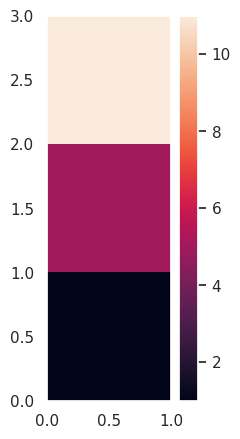

In [ ]:
single_encoder_hidden_state = np.array([1, 5, 11]).astype(float)[:, None]

plt.figure(figsize=(2, 5))
plt.pcolormesh(single_encoder_hidden_state)
plt.colorbar()

In [ ]:
# вектор внимания как скалярное произведение
np.dot(decoder_hidden_state.T, single_encoder_hidden_state)

array([[106.]])

Обобщим на случай, когда у энкодера несколько скрытых состояний:

In [ ]:
encoder_hidden_states = np.array([
    [1, 5, 11],
    [7, 4, 1],
    [8, 12, 2],
    [-9, 0, 1]

]).astype(float).T

encoder_hidden_states

array([[ 1.,  7.,  8., -9.],
       [ 5.,  4., 12.,  0.],
       [11.,  1.,  2.,  1.]])

In [ ]:
# функция подсчета скалярных произведений
def dot_product_attention_score(decoder_hidden_state, encoder_hidden_states):
    '''
    decoder_hidden_state: np.array of shape (n_features, 1)
    encoder_hidden_states: np.array of shape (n_features, n_states)

    return: np.array of shape (1, n_states)
        Array with dot product attention scores
    '''
    attention_scores = np.dot(decoder_hidden_state.T, encoder_hidden_states)
    return attention_scores

In [ ]:
# вектор скрытого состояния
dot_product_attention_score(decoder_hidden_state, encoder_hidden_states)

array([[106.,  97., 196., -59.]])

In [ ]:
#
def softmax(vector):
    '''
    vector: np.array of shape (n, m)

    return: np.array of shape (n, m)
        Matrix where softmax is computed for every row independently
    '''
    nice_vector = vector - vector.max()
    exp_vector = np.exp(nice_vector)
    exp_denominator = np.sum(exp_vector, axis=1)[:, np.newaxis]
    softmax_ = exp_vector / exp_denominator
    return softmax_

In [ ]:
# вектор весов всех состояний
weights_vector = softmax(dot_product_attention_score(decoder_hidden_state, encoder_hidden_states))

weights_vector

array([[8.19401262e-040, 1.01122149e-043, 1.00000000e+000,
        1.79848622e-111]])

**Итоговый вектор внимания** представляет собой взвешенную сумму всех состояний энкодера, где веса определяются релевантностью каждого состояния энкодера текущему состоянию декодера.


In [ ]:
def dot_product_attention(decoder_hidden_state, encoder_hidden_states):
    '''
    decoder_hidden_state: np.array of shape (n_features, 1)
    encoder_hidden_states: np.array of shape (n_features, n_states)

    return: np.array of shape (n_features, 1)
        Final attention vector
    '''
    softmax_vector = softmax(dot_product_attention_score(decoder_hidden_state, encoder_hidden_states))
    attention_vector = softmax_vector.dot(encoder_hidden_states.T).T
    return attention_vector

**1)** Реализуйте мультипликативное внимание

In [ ]:
encoder_hidden_states_complex = np.array([
    [1, 5, 11, 4, -4],
    [7, 4, 1, 2, 2],
    [8, 12, 2, 11, 5],
    [-9, 0, 1, 8, 12]

]).astype(float).T

# Дана матрица весов
W_mult = np.array([
    [-0.78, -0.97, -1.09, -1.79,  0.24],
    [ 0.04, -0.27, -0.98, -0.49,  0.52],
    [ 1.08,  0.91, -0.99,  2.04, -0.15]
])

In [ ]:
def multiplicative_attention(decoder_hidden_state, encoder_hidden_states, W_mult):
    '''
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_mult: np.array of shape (n_features_dec, n_features_enc)

    return: np.array of shape (n_features_enc, 1)
        Final attention vector
    '''

    transformed_encoder = np.dot(W_mult, encoder_hidden_states)
    attention_scores = np.dot(decoder_hidden_state.T, transformed_encoder)
    attention_weights = softmax(attention_scores)
    attention_vector = attention_weights.dot(encoder_hidden_states.T).T

    return attention_vector

In [ ]:
attention_vector = multiplicative_attention(decoder_hidden_state, encoder_hidden_states_complex, W_mult)

#### Сохраните результат

In [ ]:
np.save('submission_att03.npy', attention_vector, allow_pickle=True)
print('Ответ сохранен в файл `submission_att03.npy`')

Ответ сохранен в файл `submission_att03.npy`
